# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [7]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
KAKAO_API_KEY = os.getenv('KAKAO_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 카카오 장소검색 도구

https://developers.kakao.com/docs/latest/ko/local/dev-guide#search-by-keyword

In [8]:
from langchain.tools import tool    # Tool 데코레이터
import requests                     # http(rest-api) 요청 처리
from pprint import pprint
from typing import List, TypedDict  # 타입 힌트

class kakaoPlace(TypedDict):
    name : str
    address : str
    url : str

# 키워드를 이용해 카카오 장소 검색을 수행하는 툴
@tool
def kakao_place_search(query:str) -> List[kakaoPlace]:
    """
    카카오 장소검색 API를 호출하기 위한 도구

    Args:
        query: 검색어(키워드 기반)
    Returns:
        검색 결과
    """
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization': f"KakaoAK {KAKAO_API_KEY}"
    }
    params = {'query': query, 'size': 5}
    response = requests.get(url, headers=headers, params=params)
    data = response.json()
    data = data['documents']

    return [
        {
            'name' : place['place_name'],
            'address': place['address_name'],
            'url':place['place_url']
        } for place in data
    ]

pprint(kakao_place_search.invoke({'query': '독산동 맛집'}))

[{'address': '서울 금천구 독산동 163-2',
  'name': '왕래성',
  'url': 'http://place.map.kakao.com/538642507'},
 {'address': '서울 금천구 독산동 179-8',
  'name': '청정회센터',
  'url': 'http://place.map.kakao.com/9965001'},
 {'address': '서울 금천구 독산동 288-9',
  'name': '불맛전문관사부간짬뽕 독산직영점',
  'url': 'http://place.map.kakao.com/962610671'},
 {'address': '서울 금천구 독산동 1113',
  'name': '소하떡집',
  'url': 'http://place.map.kakao.com/1448413740'},
 {'address': '서울 금천구 독산동 378-428',
  'name': '돈유창',
  'url': 'http://place.map.kakao.com/1002142708'}]


# 키워드 추출 도구

In [9]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate

llm = init_chat_model('gpt-5.6-luna')

@tool
def extract_keyword(user_request: str) -> str:
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """
    prompt = PromptTemplate.from_template('''
당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
- 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
- 다른 설명은 하지말고, 키워드만 추출합니다.

[사용자요청]
{user_request}


[예시]
- 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
- 부산 핫플 좀 알려줘봐 -> 부산 맛집

[금지어]
- 소문난
- 핫플
''')

    chain = prompt | llm
    response = chain.invoke({'user_request': user_request})
    return response.content.strip().strip('"\'')

print(extract_keyword.invoke('여기 독산역 근처인데, 소문난 맛집 좀 알려줘'))
print(extract_keyword.invoke('여기 독산역 근처인데, 책 읽기 좋은 카페 알려줘'))
print(extract_keyword.invoke('여기 독산역 근처인데, 가장 가까운 올리브영이 얼마나 걸려?'))

독산역 맛집
독산역 책 읽기 좋은 카페
독산역 올리브영


# 그래프 구성
- 키워드 구성

In [10]:
from langgraph.graph import StateGraph, START, END          # 그래프 구성 요소
from langgraph.prebuilt import ToolNode, tools_condition    # 도구 노드, 분기 조건
from typing import Annotated, Optional     # 타입 힌트 도구
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, ToolMessage

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장
    search_query : Optional[str]
    search_results : Optional[List[kakaoPlace]]

# gpt-5.6-luna는 chat completions에서 function tools + reasoning_effort 조합을 지원하지 않으므로 'none'으로 지정
llm = init_chat_model('gpt-5.6-luna', reasoning_effort='none')
tools = [kakao_place_search, extract_keyword]         # 키워드 추출 + 장소 검색 도구
llm_with_tools = llm.bind_tools(tools)

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    update = {}
    last = state['messages'][-1]
    if isinstance(last, ToolMessage):          # 직전에 도구를 실행한 경우
        if last.name == 'extract_keyword':
            update['search_query'] = last.content
        elif last.name == 'kakao_place_search':
            update['search_results'] = last.content

    update['messages'] = [llm_with_tools.invoke(state['messages'])]  # tools가 바인딩된 llm으로 호출
    return update  # 변경된 필드만 반환 (add_messages 규칙으로 messages는 누적)

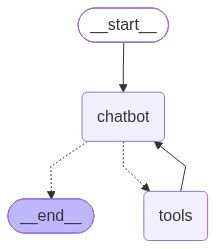

In [11]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

builder = StateGraph(State)     # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_edge(START, 'chatbot')                         # 시작 노드 -> chatbot 노드
builder.add_conditional_edges('chatbot', tools_condition)  # chatbot -> (tools | END)
builder.add_edge('tools', 'chatbot')                       # tools -> chatbot

graph = builder.compile(checkpointer=memory)  # 체크포인터를 포함하여 컴파일

graph  # 그래프 객체

# 그래프 실행

In [12]:
initial_state: State = {
    'messages': [('human', '독산역 구내식당 맛집 알려줘')],
    'search_query': None,
    'search_results': None
}

# 체크포인터를 사용하므로 thread_id가 담긴 config를 함께 전달해야 함
config = {'configurable': {'thread_id': 'user1'}}
final_state = graph.invoke(initial_state, config)
final_state

{'messages': [HumanMessage(content='독산역 구내식당 맛집 알려줘', additional_kwargs={}, response_metadata={}, id='07961ef1-3db1-47b8-bb6a-f1e5f3af5392'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 223, 'total_tokens': 251, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 'id': 'chatcmpl-EJw977NRUJDIWJG0xm5Xv0uXTtvuQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0662a-727d-79f2-ac9a-bbb0a69dfda6-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '독산역 구내식당 맛집 알려줘'}, 'id': 'call_Dz9uPYmsTsCHhleP3Ls1MxQu', 'type': 'to

In [14]:
from IPython.display import Markdown 

Markdown(final_state['messages'][-1].content)

독산역 인근 구내식당으로 검색되는 곳은 다음과 같습니다.

- **다온푸드** — 서울 금천구 가산동 673  
  [카카오맵에서 보기](http://place.map.kakao.com/1730488332)
- **좋은데** — 서울 금천구 가산동 680  
  [카카오맵에서 보기](http://place.map.kakao.com/382341238)
- **런치투게더** — 서울 금천구 가산동 319-8  
  [카카오맵에서 보기](http://place.map.kakao.com/544428179)
- **런치타임** — 서울 금천구 가산동 327-30  
  [카카오맵에서 보기](http://place.map.kakao.com/947488989)
- **호서구내식당** — 서울 금천구 가산동 319  
  [카카오맵에서 보기](http://place.map.kakao.com/1899737733)

구내식당은 **운영시간·식단·외부인 이용 가능 여부가 자주 바뀌므로 방문 전 전화나 최신 리뷰 확인**을 추천합니다. 독산역에서 가까운 곳을 우선 찾는다면 가산동 **319번지 일대의 호서구내식당·런치투게더**부터 확인해 보세요.

In [16]:
# LangGraph 스트리밍 실행 : 노드별 상태 변화를 실시간 확인

initial_state: State = {
    'messages': [('human', '독산역 구내식당 맛집 알려줘')],
    'search_query': None,
    'search_results': None
}

# 체크포인터가 붙은 그래프이므로 thread_id가 담긴 config 필요
config = {'configurable': {'thread_id': 'user2'}}

for chunk in graph.stream(initial_state, config, stream_mode='updates'):
    for node, update in chunk.items():
        print(f"{node} node")
        if 'messages' in update:
            update['messages'][-1].pretty_print()
    print()

chatbot node
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_iKM20WYPt6ff9uKXx0gRe98q)
 Call ID: call_iKM20WYPt6ff9uKXx0gRe98q
  Args:
    user_request: 독산역 구내식당 맛집 알려줘

tools node
================================= Tool Message =================================
Name: extract_keyword

독산역 구내식당 맛집

chatbot node
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_1A5l8Cth59TRgcq6KpUvlIsl)
 Call ID: call_1A5l8Cth59TRgcq6KpUvlIsl
  Args:
    query: 독산역 구내식당

tools node
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "다온푸드", "address": "서울 금천구 가산동 673", "url": "http://place.map.kakao.com/1730488332"}, {"name": "좋은데", "address": "서울 금천구 가산동 680", "url": "http://place.map.kakao.com/382341238"}, {"name": "런치투게더", "address": "서울 금천구 가산동 319-8", "url": "http://place.map.kakao.com/544428179"}, {